# Modele lineaire -- Cas de tests & visualisations

Plan :
1. Cas logiques : OR (lineairement separable), XOR (non separable)
2. Frontiere de decision : OR vs XOR
3. Cas reel : classification d'images (chats / chiens / autres)


In [1]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join("..", "python")))

from ctypes import c_double
from functions import get_linear_lib

lib = get_linear_lib()


## 1. Cas logiques

In [2]:
def run_logic_test(lib, name, inputs, labels, epochs=5000):
    print(f"\n=== Porte {name} ===")
    model = lib.create_linear_model(2, 2)

    # Entrainement
    for _ in range(epochs):
        for i in range(len(inputs)):
            c_features = (c_double * 2)(*inputs[i])
            lib.train_one_linear(model, c_features, labels[i], 0.01)

    # Verification
    success = True
    for i in range(len(inputs)):
        c_features = (c_double * 2)(*inputs[i])
        res = lib.predict_linear(model, c_features)
        ok = (res == labels[i])
        success = success and ok
        print(f"  entree {inputs[i]} | attendu {labels[i]} | predit {res}  {'OK' if ok else 'ERREUR'}")
    print(f"  -> {name} : {'SUCCES' if success else 'ECHEC'}")

    lib.destroy_linear_model(model)
    return model, success


inputs_or = [[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]]
labels_or = [0, 1, 1, 1]
run_logic_test(lib, "OR", inputs_or, labels_or)

inputs_xor = [[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]]
labels_xor = [0, 1, 1, 0]
run_logic_test(lib, "XOR", inputs_xor, labels_xor)



=== Porte OR ===
  entree [0.0, 0.0] | attendu 0 | predit 0  OK
  entree [0.0, 1.0] | attendu 1 | predit 1  OK
  entree [1.0, 0.0] | attendu 1 | predit 1  OK
  entree [1.0, 1.0] | attendu 1 | predit 1  OK
  -> OR : SUCCES

=== Porte XOR ===
  entree [0.0, 0.0] | attendu 0 | predit 1  ERREUR
  entree [0.0, 1.0] | attendu 1 | predit 0  ERREUR
  entree [1.0, 0.0] | attendu 1 | predit 0  ERREUR
  entree [1.0, 1.0] | attendu 0 | predit 0  OK
  -> XOR : ECHEC


(1965286984672, False)

## 2. Frontiere de decision : OR vs XOR

OR est lineairement separable (une droite suffit), XOR ne l'est pas : le modele
lineaire echoue forcement sur XOR, quel que soit le nombre d'epochs.


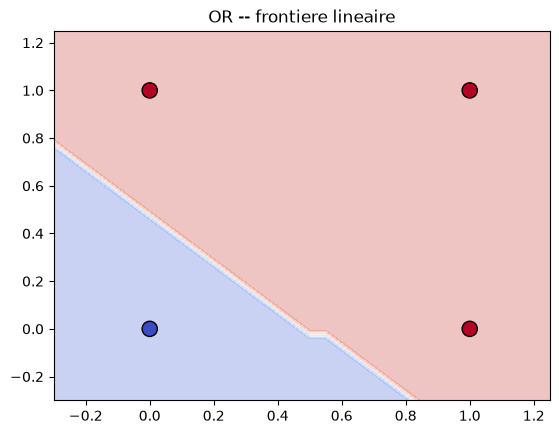

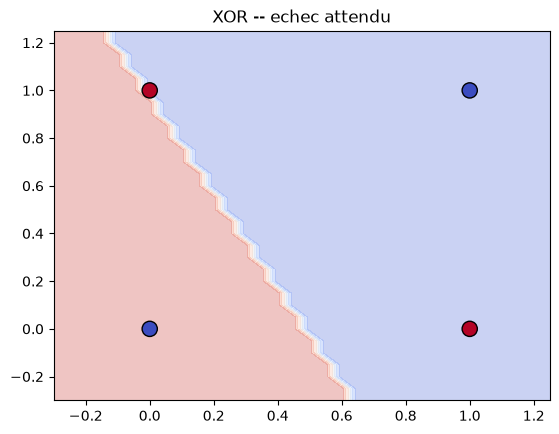

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def entrainer(lib, inputs, labels, epochs=5000, lr=0.01):
    model = lib.create_linear_model(2, 2)
    for _ in range(epochs):
        for i in range(len(inputs)):
            c_features = (c_double * 2)(*inputs[i])
            lib.train_one_linear(model, c_features, labels[i], lr)
    return model

def predire(lib, model, point):
    c_features = (c_double * 2)(*point)
    return lib.predict_linear(model, c_features)

def dessiner_frontiere(lib, model, X, labels, titre):
    X = np.array(X, dtype=float)

    pas = 0.05
    valeurs_x = np.arange(X[:, 0].min() - 0.3, X[:, 0].max() + 0.3, pas)
    valeurs_y = np.arange(X[:, 1].min() - 0.3, X[:, 1].max() + 0.3, pas)

    Z = []
    for y in valeurs_y:
        ligne = []
        for x in valeurs_x:
            classe = predire(lib, model, [x, y])
            ligne.append(classe)
        Z.append(ligne)

    plt.contourf(valeurs_x, valeurs_y, Z, alpha=0.3, cmap="coolwarm")
    plt.scatter(X[:, 0], X[:, 1], c=labels, cmap="coolwarm", edgecolors="k", s=120)
    plt.title(titre)
    plt.show()


model_or = entrainer(lib, inputs_or, labels_or)
dessiner_frontiere(lib, model_or, inputs_or, labels_or, "OR -- frontiere lineaire")
lib.destroy_linear_model(model_or)

model_xor = entrainer(lib, inputs_xor, labels_xor)
dessiner_frontiere(lib, model_xor, inputs_xor, labels_xor, "XOR -- echec attendu")
lib.destroy_linear_model(model_xor)


## 3. Cas reel : classification d'images

Dataset chats / chiens / autres, pixels
1. **peu d'images, peu d'epochs** (le pire cas)
2. **plus d'images, peu d'epochs** (effet de la taille du dataset)
3. **plus d'images, plus d'epochs** (effet de l'entrainement)


In [4]:
import numpy as np
from functions import load_dataset

project_root = os.path.abspath("..")
train_folder = os.path.join(project_root, "dataset", "train_dataset")
test_folder = os.path.join(project_root, "dataset", "test_dataset")

# 32x32, gris / rgb
X_train_32_1, Y_train_32_1 = load_dataset(train_folder, target_size=(32, 32))
X_test_32_1, Y_test_32_1 = load_dataset(test_folder, target_size=(32, 32))
X_train_32_3, Y_train_32_3 = load_dataset(train_folder, target_size=(32, 32), color=True)
X_test_32_3, Y_test_32_3 = load_dataset(test_folder, target_size=(32, 32), color=True)

# 16x16, gris / rgb
X_train_16_1, Y_train_16_1 = load_dataset(train_folder, target_size=(16, 16))
X_test_16_1, Y_test_16_1 = load_dataset(test_folder, target_size=(16, 16))
X_train_16_3, Y_train_16_3 = load_dataset(train_folder, target_size=(16, 16), color=True)
X_test_16_3, Y_test_16_3 = load_dataset(test_folder, target_size=(16, 16), color=True)

print(f"32x32 -- train: {len(X_train_32_1)} (gris) / {len(X_train_32_3)} (couleur)")
print(f"16x16 -- train: {len(X_train_16_1)} (gris) / {len(X_train_16_3)} (couleur)")


32x32 -- train: 2400 (gris) / 2400 (couleur)
16x16 -- train: 2400 (gris) / 2400 (couleur)


In [5]:
results = []  # historique de tous les runs

def run_linear(X_train, Y_train, X_test, Y_test, resolution, couleur, epochs, lr, n_train=None, n_test=None, seed=42):
    rng = np.random.RandomState(seed)
    perm = rng.permutation(len(X_train))
    X_train = [X_train[i] for i in perm][:n_train]
    Y_train = [Y_train[i] for i in perm][:n_train]
    X_test = X_test[:n_test]
    Y_test = Y_test[:n_test]

    model = lib.create_linear_model(len(X_train[0]), 3)
    for _ in range(epochs):
        for x, y in zip(X_train, Y_train):
            lib.train_one_linear(model, x, y, lr)

    def accuracy(X, Y):
        correct = sum(lib.predict_linear(model, x) == y for x, y in zip(X, Y))
        return correct / len(X) * 100

    r = {
        "resolution": resolution, "couleur": couleur,
        "epochs": epochs, "lr": lr, "n_train": len(X_train),
        "train_acc": accuracy(X_train, Y_train),
        "test_acc": accuracy(X_test, Y_test),
    }
    results.append(r)

    canal = "couleur" if couleur else "gris"
    print(f"{resolution}x{resolution} {canal} | epochs={epochs} lr={lr} n_train={r['n_train']} "
          f"-> train={r['train_acc']:.2f}% test={r['test_acc']:.2f}%")

    lib.destroy_linear_model(model)
    # return r

In [6]:
PEU_IMAGES = 500    
PEU_EPOCHS = 200   
PLUS_EPOCHS = 1000  
LR = 0.0001


### Cas 1 : 16x16

#### 16x16, 1 canal (gris)

In [7]:
# 16x16, gris | 500 images | 200 epochs
run_linear(X_train_16_1, Y_train_16_1, X_test_16_1, Y_test_16_1,
           resolution=16, couleur=False, epochs=PEU_EPOCHS, lr=LR, n_train=PEU_IMAGES)

# 16x16, gris | 2400 images | 200 epochs
run_linear(X_train_16_1, Y_train_16_1, X_test_16_1, Y_test_16_1,
           resolution=16, couleur=False, epochs=PEU_EPOCHS, lr=LR)

# 16x16, gris | 2400 images | 1000 epochs
run_linear(X_train_16_1, Y_train_16_1, X_test_16_1, Y_test_16_1,
           resolution=16, couleur=False, epochs=PLUS_EPOCHS, lr=LR)

16x16 gris | epochs=200 lr=0.0001 n_train=500 -> train=56.20% test=40.00%
16x16 gris | epochs=200 lr=0.0001 n_train=2400 -> train=50.50% test=44.17%
16x16 gris | epochs=1000 lr=0.0001 n_train=2400 -> train=53.29% test=41.00%


#### 16x16, 3 canaux (couleur)

In [8]:
# 16x16, couleur | 500 images | 200 epochs
run_linear(X_train_16_3, Y_train_16_3, X_test_16_3, Y_test_16_3,
           resolution=16, couleur=True, epochs=PEU_EPOCHS, lr=LR, n_train=PEU_IMAGES)

# 16x16, couleur | 2400 images | 200 epochs
run_linear(X_train_16_3, Y_train_16_3, X_test_16_3, Y_test_16_3,
           resolution=16, couleur=True, epochs=PEU_EPOCHS, lr=LR)

# 16x16, couleur | 2400 images | 1000 epochs
run_linear(X_train_16_3, Y_train_16_3, X_test_16_3, Y_test_16_3,
           resolution=16, couleur=True, epochs=PLUS_EPOCHS, lr=LR)

16x16 couleur | epochs=200 lr=0.0001 n_train=500 -> train=68.60% test=47.67%
16x16 couleur | epochs=200 lr=0.0001 n_train=2400 -> train=59.88% test=52.50%
16x16 couleur | epochs=1000 lr=0.0001 n_train=2400 -> train=63.29% test=49.17%


### Cas 2 : 32x32

#### 32x32, 1 canal (gris)

In [9]:
# 32x32, gris | 500 images | 200 epochs
run_linear(X_train_32_1, Y_train_32_1, X_test_32_1, Y_test_32_1,
           resolution=32, couleur=False, epochs=PEU_EPOCHS, lr=LR, n_train=PEU_IMAGES)

# 32x32, gris | 2400 images | 200 epochs
run_linear(X_train_32_1, Y_train_32_1, X_test_32_1, Y_test_32_1,
           resolution=32, couleur=False, epochs=PEU_EPOCHS, lr=LR)

# 32x32, gris | 2400 images | 1000 epochs
run_linear(X_train_32_1, Y_train_32_1, X_test_32_1, Y_test_32_1,
           resolution=32, couleur=False, epochs=PLUS_EPOCHS, lr=LR)

32x32 gris | epochs=200 lr=0.0001 n_train=500 -> train=77.00% test=38.67%
32x32 gris | epochs=200 lr=0.0001 n_train=2400 -> train=62.50% test=38.83%
32x32 gris | epochs=1000 lr=0.0001 n_train=2400 -> train=70.50% test=39.33%


#### 32x32, 3 canaux (couleur)

In [10]:
# 32x32, couleur | 500 images | 200 epochs
run_linear(X_train_32_3, Y_train_32_3, X_test_32_3, Y_test_32_3,
           resolution=32, couleur=True, epochs=PEU_EPOCHS, lr=LR, n_train=PEU_IMAGES)

# 32x32, couleur | 2400 images | 200 epochs
run_linear(X_train_32_3, Y_train_32_3, X_test_32_3, Y_test_32_3,
           resolution=32, couleur=True, epochs=PEU_EPOCHS, lr=LR)

# 32x32, couleur | 2400 images | 1000 epochs
run_linear(X_train_32_3, Y_train_32_3, X_test_32_3, Y_test_32_3,
           resolution=32, couleur=True, epochs=PLUS_EPOCHS, lr=LR)

32x32 couleur | epochs=200 lr=0.0001 n_train=500 -> train=91.60% test=41.50%
32x32 couleur | epochs=200 lr=0.0001 n_train=2400 -> train=74.92% test=46.50%
32x32 couleur | epochs=1000 lr=0.0001 n_train=2400 -> train=83.21% test=44.17%


#### Effet du learning rate sur les meilleures configs

- **16x16 couleur**, 2400 images, 200 epochs 
- **32x32 couleur**, 2400 images, 200 epochs


In [11]:
LR_VALUES = [0.1, 0.01, 0.001, 0.005, 0.00001, 0.00005]

print("===== 16x16 couleur | 2400 images | 200 epochs =====")
for lr in LR_VALUES:
    run_linear(X_train_16_3, Y_train_16_3, X_test_16_3, Y_test_16_3,
               resolution=16, couleur=True, epochs=PEU_EPOCHS, lr=lr)

print()

print("===== 32x32 couleur | 2400 images | 200 epochs =====")
for lr in LR_VALUES:
    run_linear(X_train_32_3, Y_train_32_3, X_test_32_3, Y_test_32_3,
               resolution=32, couleur=True, epochs=PEU_EPOCHS, lr=lr)

===== 16x16 couleur | 2400 images | 200 epochs =====
16x16 couleur | epochs=200 lr=0.1 n_train=2400 -> train=33.33% test=33.33%
16x16 couleur | epochs=200 lr=0.01 n_train=2400 -> train=57.21% test=42.50%
16x16 couleur | epochs=200 lr=0.001 n_train=2400 -> train=63.00% test=47.83%
16x16 couleur | epochs=200 lr=0.005 n_train=2400 -> train=63.67% test=44.67%
16x16 couleur | epochs=200 lr=1e-05 n_train=2400 -> train=54.87% test=51.67%
16x16 couleur | epochs=200 lr=5e-05 n_train=2400 -> train=58.42% test=52.00%

===== 32x32 couleur | 2400 images | 200 epochs =====
32x32 couleur | epochs=200 lr=0.1 n_train=2400 -> train=33.33% test=33.33%
32x32 couleur | epochs=200 lr=0.01 n_train=2400 -> train=33.33% test=33.33%
32x32 couleur | epochs=200 lr=0.001 n_train=2400 -> train=79.00% test=42.33%
32x32 couleur | epochs=200 lr=0.005 n_train=2400 -> train=57.79% test=37.83%
32x32 couleur | epochs=200 lr=1e-05 n_train=2400 -> train=61.79% test=52.67%
32x32 couleur | epochs=200 lr=5e-05 n_train=2400 -> 

## 5. Recap final

In [12]:
top5 = sorted(results, key=lambda r: r["test_acc"], reverse=True)[:5]

print(f"{'Config':<14}{'Params':>8}{'N_train':>9}{'Epochs':>8}{'LR':>10}{'Train%':>9}{'Test%':>8}")
print("-" * 66)
for r in top5:
    canal = "couleur" if r["couleur"] else "gris"
    config = f"{r['resolution']}x{r['resolution']} {canal}"
    params = r["resolution"] ** 2 * (3 if r["couleur"] else 1)
    print(f"{config:<14}{params:>8}{r['n_train']:>9}{r['epochs']:>8}"
          f"{r['lr']:>10}{r['train_acc']:>8.2f}%{r['test_acc']:>7.2f}%")


Config          Params  N_train  Epochs        LR   Train%   Test%
------------------------------------------------------------------
32x32 couleur     3072     2400     200     1e-05   61.79%  52.67%
16x16 couleur      768     2400     200    0.0001   59.88%  52.50%
16x16 couleur      768     2400     200     5e-05   58.42%  52.00%
16x16 couleur      768     2400     200     1e-05   54.87%  51.67%
16x16 couleur      768     2400    1000    0.0001   63.29%  49.17%


## 6. Sauvegarde du meilleur modele

Config retenue : **16x16 couleur**, 200 epochs, lr=0.0001, 2400 images
(meilleur compromis precision/params, cf section 5).

In [15]:
from functions import save_model

model = lib.create_linear_model(16 * 16 * 3, 3)
for _ in range(200):
    for x, y in zip(X_train_16_3, Y_train_16_3):
        lib.train_one_linear(model, x, y, 0.0001)

chemin = os.path.join(project_root, "models", "linear_chat_chien_autre.bin")
save_model(lib, model, chemin)
lib.destroy_linear_model(model)

print(f"succes")

succes
